# Baseline 04b — Piloto rápido y comparativa contra US-022b

Este cuaderno cumple dos funciones acotadas que ningún otro notebook de la serie cubre:

1. **Piloto del patrón** `setup_notebook` + `train_baseline_three_models` en menos de 10 minutos sobre un subsample del dataset Italia. Sirve para validar que el tooling completo (carga, spatial CV, RF + XGB + LightGBM, persistencia y MLflow) corre end-to-end antes de comprometerse con la corrida completa del cuaderno `04_baseline.ipynb` (2-3 h).
2. **Comparativa contra el baseline previo US-022b**, que reporta cifras de XGBoost + InceptionTime + TempCNN sobre el mismo conjunto. La tabla de deltas evidencia la evolución del proyecto: misma metodología (spatial CV 5-fold buffer 1 km), nuevo conjunto de modelos.

**Preguntas oficiales del Avance 3 a las que aporta**: P1 (algoritmo baseline) y P4 (métrica adecuada — el piloto exhibe el desbalance que hace inadecuada la accuracy).

## Requisitos

- `data/test_fixtures/feature_selection_parcels_subset.parquet` presente (descargable vía `dvc pull`).
- `data/processed/pastis_parcels_full.geoparquet` presente.
- Servidor MLflow corriendo en `http://localhost:5010`.


In [1]:
FEATURES_PATH = "data/test_fixtures/feature_selection_parcels_subset.parquet"
PARCELS_GEOPARQUET = "data/processed/pastis_parcels_full.geoparquet"
FIGURES_SUBDIR = "us-023-preview/04b_baseline"
REPORTS_SUBDIR = "baseline/04b_baseline"
K_FOLDS = 5
BUFFER_KM = 1.0
RANDOM_STATE = 42
SUBSET_SIZE = 8000  # pilot: class-stratified subsample
HCAT_SUBSET_SIZE = 8000  # piloto seccion 8 (18 vs 6 grupos HCAT) sobre subsample
MLFLOW_EXPERIMENT = "baseline-04b-pilot"


In [2]:
from __future__ import annotations

import os
import sys
from pathlib import Path

# Bootstrap: locate the repo root by searching for pyproject.toml
_HERE = Path.cwd().resolve()
for _candidate in (_HERE, *_HERE.parents):
    if (_candidate / "pyproject.toml").is_file():
        if str(_candidate) not in sys.path:
            sys.path.insert(0, str(_candidate))
        break

from ml.utils.notebook_bootstrap import setup_notebook
from IPython.display import Markdown, display

env = setup_notebook(
    figures_subdir=FIGURES_SUBDIR,
    reports_subdir=REPORTS_SUBDIR,
)
display(Markdown(env.summary_markdown()))

# Chdir to the repo root so the relative paths in the `parameters` cell
# (FEATURES_PATH = "data/...", etc.) resolve the same regardless of where
# the kernel was launched (VS Code opens with cwd = notebook folder).
# This preserves the papermill contract (parameters as relative strings) and
# avoids FileNotFoundError caused by cwd != repo root.
os.chdir(env.repo)
display(Markdown(f"**cwd anclado al repo root**: `{env.repo}`"))


| Recurso | Estado |
|---|---|
| Repo root | `C:\Users\arthu\Proyectos\MNA\agro_sat_copilot` |
| Figures dir | `paper\figures\us-023-preview\04b_baseline` |
| Reports dir | `reports\baseline\04b_baseline` |
| Gemini API key | presente |
| Earth Engine | configurado |
| GEE project | `agrosat-copilot` |

**cwd anclado al repo root**: `C:\Users\arthu\Proyectos\MNA\agro_sat_copilot`

### Trazabilidad MLflow

Cada modelo del piloto abre un run propio en el experimento `baseline-04b-pilot` con los tags `code_version` y `data_version`. Los runs quedan separados del experimento principal `baseline-04-tabular` para distinguir piloto-sobre-subset de corrida-completa.

In [4]:
from ml.utils.mlflow_utils import (
    resolve_tracking_uri,
    track_experiment,
    server_is_reachable,
)

# Robust tracking URI resolution: if MLFLOW_TRACKING_URI is set in
# `.env.local` but the server does not respond (Docker off, container
# stopped), we fall back to `file:./mlruns` so the notebook keeps running.
_candidate_uri = resolve_tracking_uri(None, probe_server=False)
if _candidate_uri.startswith(('http://', 'https://')) and not server_is_reachable(_candidate_uri):
    mlflow_uri = 'file:./mlruns'
    display(Markdown(
        f'> Servidor MLflow `{_candidate_uri}` no responde. '
        'Caigo a tracking local `file:./mlruns`. '
        'Para registrar en el server, ejecuta `docker compose up -d mlflow` '
        'antes de re-ejecutar las celdas MLflow.'
    ))
else:
    mlflow_uri = _candidate_uri
display(Markdown(
    f'**MLflow tracking URI**: `{mlflow_uri}` · '
    f'**Experimento**: `{MLFLOW_EXPERIMENT}`'
))
MLFLOW_RUN_IDS: dict[str, str] = {}


**MLflow tracking URI**: `http://localhost:5010` · **Experimento**: `baseline-04b-pilot`

## 1. Carga del dataset + subsample estratificado

Cargamos el subset US-018 con metadata enriquecida del geoparquet y submuestreamos estratificando por `class_id` para preservar la distribución de clases. El subsample mantiene la proporción del desbalance — la imagen del problema no cambia, solo el tamaño.

In [5]:
import polars as pl
import numpy as np
from ml.utils.baseline_notebook_helpers import (
    load_features_dataset_with_meta,
    train_baseline_three_models,
    build_model_comparison_table,
)
from ml.utils.class_distribution import (
    class_distribution_report,
    recommend_threshold,
)

df_full = load_features_dataset_with_meta(
    path=FEATURES_PATH,
    parcels_geoparquet=PARCELS_GEOPARQUET,
)

# Class-stratified subsample: keeps the original proportions.
rng = np.random.default_rng(RANDOM_STATE)
frac = min(1.0, SUBSET_SIZE / df_full.height)
df = (
    df_full.with_columns(pl.lit(rng.random(df_full.height)).alias('__r'))
    .group_by('class_id')
    .map_groups(lambda g: g.sort('__r').head(max(1, int(g.height * frac))))
    .drop('__r')
)
display(Markdown(
    f"**Dataset piloto**: `{df.height:,}` parcelas "
    f"(`{df.height / df_full.height * 100:.1f}%` del completo, "
    f"`{df.width}` cols)."
))
display(df.group_by('class_id').len().sort('len', descending=True).head(10))


2026-05-29 08:30:44 [info     ] features_meta_overlap_dropped  overlap=['patch_id', 'instance_id', 'fold', 'n_pixels']
2026-05-29 08:30:44 [info     ] features_loaded_with_meta      enriched_shape=(85951, 194) features_shape=(85951, 192)


**Dataset piloto**: `7,991` parcelas (`9.3%` del completo, `194` cols).

class_id,len
i64,u32
1,2912
3,1221
8,990
2,763
14,295
16,279
4,257
12,243
5,164


## 2. Distribución de clases del subset

Corroboramos que el subsample preserva la proporción original. El umbral del percentil 25 se recalcula sobre el subset porque los conteos absolutos son menores.

In [6]:
report = class_distribution_report(df)
display(report)
threshold_p25 = recommend_threshold(report, method='p25')
imbalance = float(report.get_column('n_parcels').max()) / max(
    float(report.get_column('n_parcels').min()), 1.0
)
display(Markdown(
    f'**Imbalance ratio (max/min)**: `{imbalance:.1f}x`. '
    f'**Umbral P25**: `{threshold_p25}` parcelas. '
    'El desbalance del piloto es comparable al del dataset completo.'
))


2026-05-29 08:30:49 [info     ] class_distribution_report      n_classes=18 n_high=2 n_low=10 n_med=6 n_total=7991 n_very_low=0


class_id,n_parcels,share,support_band,class_name,agronomic_group,phenological_cycle
i64,u32,f64,str,str,str,str
1,2912,0.36441,"""high""","""Meadow""","""permanent_long_cycle""","""other"""
3,1221,0.152797,"""high""","""Corn""","""cereals""","""spring_summer_crops"""
8,990,0.123889,"""med""","""Grapevine""","""permanent_long_cycle""","""permanent_crops"""
2,763,0.095482,"""med""","""Soft winter wheat""","""cereals""","""winter_crops"""
14,295,0.036917,"""med""","""Leguminous fodder""","""oilseeds_legumes""","""other"""
16,279,0.034914,"""med""","""Orchard""","""permanent_long_cycle""","""permanent_crops"""
4,257,0.032161,"""med""","""Winter barley""","""cereals""","""winter_crops"""
12,243,0.030409,"""med""","""Fruits, vegetables, flowers""","""special_crops""","""other"""
5,164,0.020523,"""low""","""Winter rapeseed""","""oilseeds_legumes""","""winter_crops"""


**Imbalance ratio (max/min)**: `57.1x`. **Umbral P25**: `91` parcelas. El desbalance del piloto es comparable al del dataset completo.

## 3. Entrenamiento RF + XGB + LightGBM con MLflow tracking

Los tres modelos comparten el mismo CV espacial y `random_state`. Cada uno abre su propio run MLflow con métricas, parámetros y tags estándar para reproducibilidad.

In [7]:
rows = train_baseline_three_models(
    df,
    models=('rf', 'xgb', 'lgbm'),
    k_folds=K_FOLDS,
    buffer_km=BUFFER_KM,
    random_state=RANDOM_STATE,
)
comparison_path = env.reports_dir / 'model_comparison_04b.parquet'
comparison = build_model_comparison_table(rows, output_path=comparison_path)
display(Markdown(f'**Tabla guardada**: `{comparison_path.relative_to(env.repo)}`'))
display(comparison)

for r in rows:
    with track_experiment(
        experiment_name=MLFLOW_EXPERIMENT,
        run_name=f'04b-{r.model}',
        tracking_uri=mlflow_uri,
        dvc_path=FEATURES_PATH,
        probe_server=False,
    ) as run:
        import mlflow
        mlflow.log_params({
            'model': r.model,
            'k_folds': K_FOLDS,
            'buffer_km': BUFFER_KM,
            'random_state': RANDOM_STATE,
            'n_parcels': df.height,
            'subset_size_target': SUBSET_SIZE,
            'is_pilot': True,
        })
        mlflow.log_metrics({
            'f1_macro': r.f1_macro,
            'f1_weighted': r.f1_weighted,
            'miou': r.miou,
            'accuracy': r.accuracy,
            'kappa': r.cohen_kappa,
            'train_time_s': r.train_time_s,
        })
        MLFLOW_RUN_IDS[r.model] = run.info.run_id
display(Markdown('**MLflow runs**: ' + ', '.join(
    f'`{k}={v[:12]}...`' for k, v in MLFLOW_RUN_IDS.items()
)))


2026-05-29 08:30:58 [info     ] spatial_folds_cache_hit        n_folds=5 path=data\test_fixtures\baseline_spatial_folds_n7991_k5_b1_s42.parquet
2026-05-29 08:30:58 [info     ] spatial_cv_start               n_classes=18 n_folds=5
2026-05-29 08:30:58 [info     ] spatial_cv_fold_start          fold=1/5 n_test=2152 n_train=5839
2026-05-29 08:30:58 [info     ] scaler_persisted               n_features=185 n_train=5839 path=C:\Users\arthu\AppData\Local\Temp\tmpgrwig1la\fold_0_scaler.joblib version=v1
2026-05-29 08:30:59 [info     ] spatial_cv_fold_done           f1_macro=0.3626 fold=1/5
2026-05-29 08:30:59 [info     ] spatial_cv_fold_start          fold=2/5 n_test=815 n_train=7176
2026-05-29 08:30:59 [info     ] scaler_persisted               n_features=185 n_train=7176 path=C:\Users\arthu\AppData\Local\Temp\tmp4xk6k29c\fold_1_scaler.joblib version=v1
2026-05-29 08:31:00 [info     ] spatial_cv_fold_done           f1_macro=0.3595 fold=2/5
2026-05-29 08:31:00 [info     ] spatial_cv_fold_start

c:\Users\arthu\AppData\Local\pypoetry\Cache\virtualenvs\agrosatcopilot-Kq8fUqSH-py3.12\Lib\site-packages\xgboost\core.py:751: UserWarning: [08:31:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


2026-05-29 08:31:38 [info     ] spatial_cv_fold_done           f1_macro=0.3975 fold=1/5
2026-05-29 08:31:38 [info     ] spatial_cv_fold_start          fold=2/5 n_test=815 n_train=7176
2026-05-29 08:31:38 [info     ] scaler_persisted               n_features=185 n_train=7176 path=C:\Users\arthu\AppData\Local\Temp\tmpg2hipb2x\fold_1_scaler.joblib version=v1
2026-05-29 08:31:38 [info     ] xgb_device_resolved            device=cuda gpu='NVIDIA GeForce RTX 4070 Laptop GPU'
2026-05-29 08:32:16 [info     ] spatial_cv_fold_done           f1_macro=0.3727 fold=2/5
2026-05-29 08:32:16 [info     ] spatial_cv_fold_start          fold=3/5 n_test=2137 n_train=5854
2026-05-29 08:32:16 [info     ] scaler_persisted               n_features=185 n_train=5854 path=C:\Users\arthu\AppData\Local\Temp\tmpuxrxd67y\fold_2_scaler.joblib version=v1
2026-05-29 08:32:16 [info     ] xgb_device_resolved            device=cuda gpu='NVIDIA GeForce RTX 4070 Laptop GPU'
2026-05-29 08:32:52 [info     ] spatial_cv_fold_don

c:\Users\arthu\AppData\Local\pypoetry\Cache\virtualenvs\agrosatcopilot-Kq8fUqSH-py3.12\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


2026-05-29 08:34:42 [info     ] scaler_persisted               n_features=185 n_train=7176 path=C:\Users\arthu\AppData\Local\Temp\tmp88udc5j9\fold_1_scaler.joblib version=v1
2026-05-29 08:35:05 [info     ] spatial_cv_fold_done           f1_macro=0.3754 fold=2/5
2026-05-29 08:35:05 [info     ] spatial_cv_fold_start          fold=3/5 n_test=2137 n_train=5854
2026-05-29 08:35:05 [info     ] scaler_persisted               n_features=185 n_train=5854 path=C:\Users\arthu\AppData\Local\Temp\tmp_9yufpue\fold_2_scaler.joblib version=v1


...

2026-05-29 08:36:28 [info     ] baseline_trained               f1_macro_oof=0.3799365014537159 model=lgbm n_classes=18 n_features=185 n_samples=7991
2026-05-29 08:36:28 [info     ] baseline_model_done            f1_macro=0.3799 model=lgbm train_time_s=127.1
2026-05-29 08:36:28 [info     ] model_comparison_persisted     path=C:\Users\arthu\Proyectos\MNA\agro_sat_copilot\reports\baseline\04b_baseline\model_comparison_04b.parquet


**Tabla guardada**: `reports\baseline\04b_baseline\model_comparison_04b.parquet`

model,f1_macro,f1_weighted,miou,accuracy,cohen_kappa,train_time_s,n_features,n_samples
str,f64,f64,f64,f64,f64,f64,i64,i64
"""lgbm""",0.3799,0.5985,0.2774,0.6441,0.5419,127.1,185,7991
"""xgb""",0.3733,0.5961,0.273,0.637,0.5357,196.6,185,7991
"""rf""",0.3502,0.5853,0.2474,0.5898,0.4963,6.4,185,7991


2026-05-29 08:37:54 [info     ] mlflow_run_started             code_version=d669ecdba1707b77ac077b2fec75149625c28713 data_version=data/test_fixtures/feature_selection_parcels_subset.parquet@4f49f4f2d22013d7ccad787727119bac experiment=baseline-04b-pilot run_id=683b4b1613374e5eb389e5cbd0f292d8 run_name=04b-rf tracking_uri=http://localhost:5010
🏃 View run 04b-rf at: http://localhost:5010/#/experiments/2/runs/683b4b1613374e5eb389e5cbd0f292d8
🧪 View experiment at: http://localhost:5010/#/experiments/2
2026-05-29 08:40:43 [info     ] mlflow_run_started             code_version=d669ecdba1707b77ac077b2fec75149625c28713 data_version=data/test_fixtures/feature_selection_parcels_subset.parquet@4f49f4f2d22013d7ccad787727119bac experiment=baseline-04b-pilot run_id=a7915d929dd74cb3b3c6e2284a9d798c run_name=04b-xgb tracking_uri=http://localhost:5010
🏃 View run 04b-xgb at: http://localhost:5010/#/experiments/2/runs/a7915d929dd74cb3b3c6e2284a9d798c
🧪 View experiment at: http://localhost:5010/#/experime

**MLflow runs**: `rf=683b4b161337...`, `xgb=a7915d929dd7...`, `lgbm=4b8c570be480...`

## 4. Comparativa contra el baseline previo US-022b

Las cifras históricas del baseline US-022b corren sobre el **conjunto completo Italia (85 951 parcelas)** con XGBoost + InceptionTime + TempCNN. Aquí comparamos lado a lado para evidenciar la evolución del proyecto: nuevo set de modelos (RF + XGB + LGBM), misma metodología.

*Nota*: los modelos temporales (TempCNN, InceptionTime) se evalúan en `05_reencuadre_fenologico.ipynb`. Aquí el delta es ilustrativo, no exhaustivo.

In [8]:
# US-022b historical figures (full set, 85951 parcels).
us022b_reference = pl.DataFrame({
    'model': ['xgboost', 'inceptiontime', 'tempcnn'],
    'f1_macro_us022b': [0.4094, 0.1865, 0.1430],
    'dataset': ['full (85951)', 'full (85951)', 'full (85951)'],
})
display(Markdown('**Referencia histórica US-022b** (mismo spatial CV 5-fold buffer 1 km):'))
display(us022b_reference)

# Name mapping between the pilot table and the historical one.
name_map = {'rf': 'random_forest', 'xgb': 'xgboost', 'lgbm': 'lightgbm'}
comparison_piloto = comparison.with_columns(
    pl.col('model').replace(name_map).alias('model_full_name')
)
joined = comparison_piloto.join(
    us022b_reference, left_on='model_full_name', right_on='model', how='left'
).select([
    'model_full_name', 'f1_macro', 'f1_macro_us022b',
    (pl.col('f1_macro') - pl.col('f1_macro_us022b')).alias('delta_piloto_vs_us022b'),
    'dataset',
])
display(Markdown('**Comparativa piloto subset vs US-022b full**:'))
display(joined)
display(Markdown(
    '> El delta esperado es ligeramente negativo (el subset reduce el F1 '
    'a igual modelo). Si el piloto está cerca del valor histórico de XGBoost '
    '(~0.41) la metodología es estable y la corrida completa de `04_baseline` '
    'puede arrancar con confianza.'
))


**Referencia histórica US-022b** (mismo spatial CV 5-fold buffer 1 km):

model,f1_macro_us022b,dataset
str,f64,str
"""xgboost""",0.4094,"""full (85951)"""
"""inceptiontime""",0.1865,"""full (85951)"""
"""tempcnn""",0.143,"""full (85951)"""


**Comparativa piloto subset vs US-022b full**:

model_full_name,f1_macro,f1_macro_us022b,delta_piloto_vs_us022b,dataset
str,f64,f64,f64,str
"""lightgbm""",0.3799,null,null,null
"""xgboost""",0.3733,0.4094,-0.0361,"""full (85951)"""
"""random_forest""",0.3502,null,null,null


> El delta esperado es ligeramente negativo (el subset reduce el F1 a igual modelo). Si el piloto está cerca del valor histórico de XGBoost (~0.41) la metodología es estable y la corrida completa de `04_baseline` puede arrancar con confianza.

## 5. F1 por clase del mejor modelo del piloto

Identifica qué clases concentran el error sobre el subset. Las clases más difíciles aquí lo seguirán siendo en la corrida completa — el subsample preserva la dificultad relativa.

**Mejor modelo del piloto**: `lgbm` (F1-macro `0.3799`)

2026-05-29 08:45:40 [info     ] spatial_folds_cache_hit        n_folds=5 path=data\test_fixtures\baseline_spatial_folds_n7991_k5_b1_s42.parquet
2026-05-29 08:45:40 [info     ] spatial_cv_start               n_classes=18 n_folds=5
2026-05-29 08:45:40 [info     ] spatial_cv_fold_start          fold=1/5 n_test=2152 n_train=5839
2026-05-29 08:45:40 [info     ] scaler_persisted               n_features=185 n_train=5839 path=C:\Users\arthu\AppData\Local\Temp\tmpxl110yhl\fold_0_scaler.joblib version=v1


c:\Users\arthu\AppData\Local\pypoetry\Cache\virtualenvs\agrosatcopilot-Kq8fUqSH-py3.12\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


2026-05-29 08:46:05 [info     ] spatial_cv_fold_done           f1_macro=0.4041 fold=1/5
2026-05-29 08:46:05 [info     ] spatial_cv_fold_start          fold=2/5 n_test=815 n_train=7176
2026-05-29 08:46:05 [info     ] scaler_persisted               n_features=185 n_train=7176 path=C:\Users\arthu\AppData\Local\Temp\tmpjbhalxdk\fold_1_scaler.joblib version=v1
2026-05-29 08:46:29 [info     ] spatial_cv_fold_done           f1_macro=0.3754 fold=2/5
2026-05-29 08:46:29 [info     ] spatial_cv_fold_start          fold=3/5 n_test=2137 n_train=5854
2026-05-29 08:46:29 [info     ] scaler_persisted               n_features=185 n_train=5854 path=C:\Users\arthu\AppData\Local\Temp\tmp45gg1rhe\fold_2_scaler.joblib version=v1


c:\Users\arthu\AppData\Local\pypoetry\Cache\virtualenvs\agrosatcopilot-Kq8fUqSH-py3.12\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


...

c:\Users\arthu\AppData\Local\pypoetry\Cache\virtualenvs\agrosatcopilot-Kq8fUqSH-py3.12\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


2026-05-29 08:49:27 [info     ] spatial_cv_fold_done           f1_macro=0.2255 fold=4/5
2026-05-29 08:49:27 [info     ] spatial_cv_fold_start          fold=5/5 n_test=962 n_train=7029
2026-05-29 08:49:27 [warning  ] scaler_replaced_inf_with_nan   examples=['MCARI_mean', 'MCARI_min', 'MCARI_max', 'MCARI_p95', 'GCVI_mean'] n_cols_affected=11 n_inf_values=3774 note='Indices espectrales con division por ~0 producen inf. Se reemplazan por NaN para imputacion por media de columna.'


c:\Users\arthu\AppData\Local\pypoetry\Cache\virtualenvs\agrosatcopilot-Kq8fUqSH-py3.12\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


2026-05-29 08:49:27 [info     ] scaler_persisted               n_features=185 n_train=7029 path=C:\Users\arthu\AppData\Local\Temp\tmp7szzrs0g\fold_4_scaler.joblib version=v1
2026-05-29 08:49:53 [info     ] spatial_cv_fold_done           f1_macro=0.3848 fold=5/5


c:\Users\arthu\AppData\Local\pypoetry\Cache\virtualenvs\agrosatcopilot-Kq8fUqSH-py3.12\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


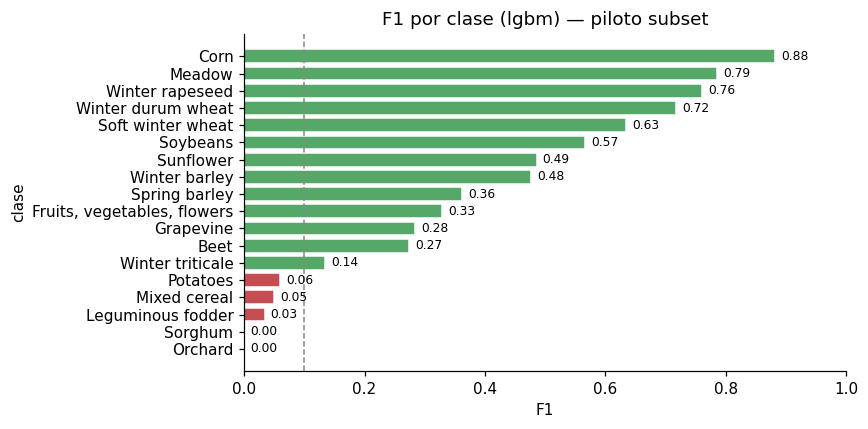

In [9]:
from ml.eval.reencuadre_plots import plot_per_class_f1
from ml.train.baseline import train_one_model, evaluate_with_spatial_cv, build_estimator
from ml.ingest.pastis_loader import PASTIS_R_CLASSES
import matplotlib.pyplot as plt

best_model = comparison['model'][0]
best_f1 = float(comparison['f1_macro'][0])
display(Markdown(
    f'**Mejor modelo del piloto**: `{best_model}` (F1-macro `{best_f1:.4f}`)'
))

best_result = train_one_model(
    df, model=best_model, k_folds=K_FOLDS,
    buffer_km=BUFFER_KM, random_state=RANDOM_STATE,
)
_cv_metrics, y_true_oof, y_pred_oof = evaluate_with_spatial_cv(
    df,
    lambda: build_estimator(best_model, best_result.best_params),
    k_folds=K_FOLDS, buffer_km=BUFFER_KM, random_state=RANDOM_STATE,
)
class_names = {
    i: PASTIS_R_CLASSES.get(int(c), f'c{int(c)}')
    for i, c in enumerate(best_result.label_classes)
}
fig = plot_per_class_f1(
    y_true_oof, y_pred_oof,
    class_labels=list(range(len(best_result.label_classes))),
    class_names=class_names,
    weak_threshold=0.10,
    title=f'F1 por clase ({best_model}) — piloto subset',
)
fig.savefig(env.figures_dir / 'per_class_f1_04b.png', bbox_inches='tight')
display(fig)
plt.close(fig)


## 8. Dos formas de medir el mismo modelo: 18 clases vs 6 grupos

El F1-macro de las secciones anteriores se calcula sobre las **18 clases planas** de PASTIS-R, y arrastra un problema estructural: varias de esas clases son **hermanas casi indistinguibles** a nivel de parcela. El trigo blando de invierno, el trigo duro de invierno, la cebada de invierno, la cebada de primavera, el triticale y el centeno mixto comparten calendario y firma espectral; separarlos con una sola imagen-resumen anual es casi imposible. Cuando el modelo confunde un trigo con otro trigo, el F1-macro lo penaliza igual que si confundiera un viñedo con una remolacha, aunque para casi cualquier uso agronómico ambos trigos pertenecen al mismo grupo.

La solución estándar en la literatura (Russwürm & Körner 2018; H2Crop 2025) es reportar también la métrica sobre una **taxonomía jerárquica**. Aquí usamos los **6 grupos HCAT Level-1** (Hierarchical Crop and Agriculture Taxonomy v3), que colapsan las 18 clases en seis familias agronómicas: cereales, oleaginosas, tubérculos, leguminosas, leñosos permanentes y otros (pradera + horticultura). Las clases hermanas caen dentro del mismo grupo, de modo que la confusión trigo-con-trigo deja de contar como error.

**Importante — qué features usa esta sección.** A diferencia de las secciones anteriores, que entrenan sobre las **185 features espectro-temporales**, aquí partimos del **escenario ganador de la ablación de bloques**: esas 185 features **más** el embedding AlphaEarth de dos años (2018 + 2019), 64 dimensiones cada uno, para un total de **313 columnas**. Por eso el F1-macro sobre las 18 clases que verás aquí es **más alto** que el de la sección 3: el salto tiene dos componentes acumulativos que conviene no confundir — primero, **añadir AlphaEarth** sube el F1 sobre el mismo esquema de 18 clases (el embedding anual aporta señal que las estadísticas espectrales no capturan); segundo, **agrupar a 6 familias** recupera el error que era pura confusión intra-familia. Las dos mejoras son reales y de naturaleza distinta: una viene de mejores features, la otra de medir la tarea a la granularidad agronómicamente correcta.

**El experimento es apples-to-apples** (mismas features, mismo spatial CV 5-fold buffer 1 km, mismo XGBoost; solo cambia la etiqueta objetivo). Aquí lo corremos sobre un **subsample estratificado** para mantener el carácter de piloto rápido: el salto de F1-macro se lee como **tendencia**, no como cifra definitiva (la cifra final, sobre las 85951 parcelas, vive en `04_baseline.ipynb`).

In [10]:
from ml.utils.baseline_notebook_helpers import (
    load_base_plus_alphaearth_2018_2019,
)
from ml.analysis.hcat_grouping import (
    HCAT_L1_GROUPS,
    HCAT_L1_GROUP_CODES,
    evaluate_flat_vs_grouped,
)
from ml.eval.reencuadre_plots import (
    plot_model_comparison_bars,
    plot_per_class_f1,
)

# Baseline reference threshold (defined locally so the section
# is self-contained in any notebook that includes it).
HCAT_F1_THRESHOLD = 0.60

# Winning ablation scenario: base (185 features) + AlphaEarth
# 2018 (ae18_NN) + AlphaEarth 2019 (ae19_NN) = 313 columns, joined
# by parcel_id (1:1 join, 0 nulls) over the 85951 parcels.
df_hcat = load_base_plus_alphaearth_2018_2019(
    features_path=FEATURES_PATH,
    parcels_geoparquet=PARCELS_GEOPARQUET,
)

# Pilot: class-stratified subsampling for a quick read.
from ml.utils.sampling import stratified_sample
df_hcat = stratified_sample(df_hcat, by=['class_id'], n=HCAT_SUBSET_SIZE, seed=RANDOM_STATE)
n_ae18 = sum(1 for c in df_hcat.columns if c.startswith('ae18_'))
n_ae19 = sum(1 for c in df_hcat.columns if c.startswith('ae19_'))
display(Markdown(
    f'**Escenario ganador**: `{df_hcat.height:,}` parcelas, '
    f'185 features base + `{n_ae18}` columnas AlphaEarth 2018 + '
    f'`{n_ae19}` columnas AlphaEarth 2019.'
))


2026-05-29 08:50:12 [info     ] features_meta_overlap_dropped  overlap=['patch_id', 'instance_id', 'fold', 'n_pixels']
2026-05-29 08:50:12 [info     ] features_loaded_with_meta      enriched_shape=(85951, 194) features_shape=(85951, 192)
2026-05-29 08:50:12 [info     ] base_plus_ae18_ae19_loaded     base_shape=(85951, 194) enriched_shape=(85951, 322) n_ae18=64 n_ae19=64 n_null_ae18=0 n_null_ae19=0


**Escenario ganador**: `7,991` parcelas, 185 features base + `64` columnas AlphaEarth 2018 + `64` columnas AlphaEarth 2019.

### 8.1 Composición de los 6 grupos HCAT Level-1

Cada grupo lista las clases PASTIS-R que absorbe y su código de nodo en la taxonomía HCAT v3 (para trazabilidad del agrupamiento). Los cereales concentran ocho clases hermanas — justamente las que se confunden entre sí en el esquema plano.

In [11]:
from ml.ingest.pastis_loader import PASTIS_R_CLASSES

grouping_rows = []
for group, class_ids in HCAT_L1_GROUPS.items():
    grouping_rows.append({
        'grupo_hcat_l1': group,
        'codigo_hcat': HCAT_L1_GROUP_CODES[group],
        'n_clases': len(class_ids),
        'clases_pastis': ', '.join(
            PASTIS_R_CLASSES.get(c, str(c)) for c in class_ids
        ),
    })
grouping_table = pl.DataFrame(grouping_rows).sort('n_clases', descending=True)
display(grouping_table)


grupo_hcat_l1,codigo_hcat,n_clases,clases_pastis
str,str,i64,str
"""CEREALS""","""3301000000""",8,"""Soft winter wheat, Corn, Winter barley, Spring barley, Winte…"
"""LEGUMES""","""3302000000""",2,"""Leguminous fodder, Soybeans"""
"""OILSEEDS""","""3303000000""",2,"""Winter rapeseed, Sunflower"""
"""OTHER""","""3300000000""",2,"""Meadow, Fruits, vegetables, flowers"""
"""PERMANENT_WOODY""","""3306000000""",2,"""Grapevine, Orchard"""
"""ROOT_CROPS""","""3304000000""",2,"""Beet, Potatoes"""


### 8.2 Entrenamiento y métricas en ambos esquemas

Entrenamos XGBoost con validación cruzada espacial dos veces sobre las mismas features: una con las 18 clases planas y otra con los 6 grupos HCAT. El helper devuelve las cinco métricas out-of-fold de cada esquema y las predicciones para los plots por clase/grupo.

In [12]:
hcat_result = evaluate_flat_vs_grouped(
    df_hcat,
    model='xgb',
    k_folds=K_FOLDS,
    buffer_km=BUFFER_KM,
    random_state=RANDOM_STATE,
)
metric_order = ['f1_macro', 'f1_weighted', 'miou', 'accuracy', 'cohen_kappa']
metric_label = {
    'f1_macro': 'F1-macro', 'f1_weighted': 'F1-weighted', 'miou': 'mIoU',
    'accuracy': 'accuracy', 'cohen_kappa': 'Cohen kappa',
}
hcat_metrics_table = pl.DataFrame({
    'metrica': [metric_label[m] for m in metric_order],
    'flat_18_clases': [round(hcat_result.flat_metrics[m], 4) for m in metric_order],
    'grouped_6_hcat': [round(hcat_result.grouped_metrics[m], 4) for m in metric_order],
    'delta': [
        round(hcat_result.grouped_metrics[m] - hcat_result.flat_metrics[m], 4)
        for m in metric_order
    ],
})
hcat_metrics_path = env.reports_dir / 'hcat_flat18_vs_grouped6.parquet'
hcat_metrics_table.write_parquet(hcat_metrics_path)
display(Markdown(
    f'**F1-macro 18 clases** = `{hcat_result.flat_metrics["f1_macro"]:.4f}` · '
    f'**F1-macro 6 grupos HCAT** = `{hcat_result.grouped_metrics["f1_macro"]:.4f}` · '
    f'**delta** = `{hcat_result.delta_f1_macro:+.4f}` '
    f'(sobre `{hcat_result.n_samples:,}` parcelas, `{hcat_result.n_features}` features)'
))
display(hcat_metrics_table)


2026-05-29 08:50:34 [info     ] spatial_folds_cache_hit        n_folds=5 path=data\test_fixtures\baseline_spatial_folds_n7991_k5_b1_s42.parquet
2026-05-29 08:50:34 [info     ] spatial_cv_start               n_classes=18 n_folds=5
2026-05-29 08:50:34 [info     ] spatial_cv_fold_start          fold=1/5 n_test=2152 n_train=5839
2026-05-29 08:50:34 [info     ] scaler_persisted               n_features=313 n_train=5839 path=C:\Users\arthu\AppData\Local\Temp\tmpczqpxnli\fold_0_scaler.joblib version=v1
2026-05-29 08:50:34 [info     ] xgb_device_resolved            device=cuda gpu='NVIDIA GeForce RTX 4070 Laptop GPU'
2026-05-29 08:51:16 [info     ] spatial_cv_fold_done           f1_macro=0.5803 fold=1/5
2026-05-29 08:51:16 [info     ] spatial_cv_fold_start          fold=2/5 n_test=815 n_train=7176
2026-05-29 08:51:16 [info     ] scaler_persisted               n_features=313 n_train=7176 path=C:\Users\arthu\AppData\Local\Temp\tmpo9fkha_2\fold_1_scaler.joblib version=v1
2026-05-29 08:51:17 [info

**F1-macro 18 clases** = `0.5442` · **F1-macro 6 grupos HCAT** = `0.7545` · **delta** = `+0.2103` (sobre `7,991` parcelas, `313` features)

metrica,flat_18_clases,grouped_6_hcat,delta
str,f64,f64,f64
"""F1-macro""",0.5442,0.7545,0.2103
"""F1-weighted""",0.7879,0.8682,0.0804
"""mIoU""",0.433,0.6354,0.2024
"""accuracy""",0.8053,0.8754,0.0701
"""Cohen kappa""",0.7572,0.8186,0.0614


### 8.3 F1-macro lado a lado

La barra de la izquierda es lo que el modelo logra cuando se le exige separar cada trigo de cada otro trigo; la de la derecha, lo que logra cuando solo se le pide acertar la familia agronómica.

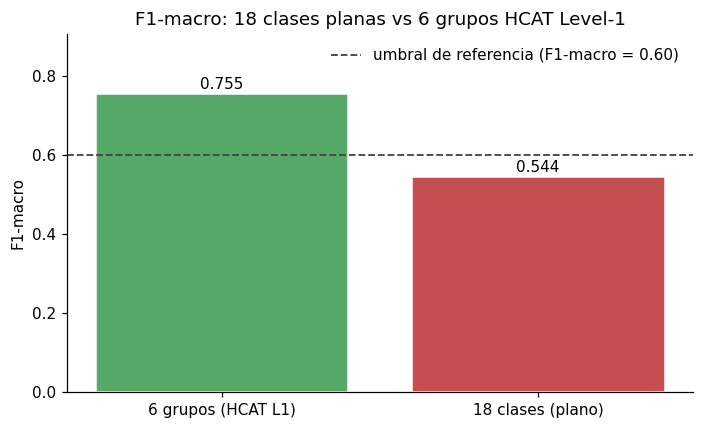

In [13]:
fig_hcat_cmp = plot_model_comparison_bars(
    {
        '18 clases (plano)': hcat_result.flat_metrics['f1_macro'],
        '6 grupos (HCAT L1)': hcat_result.grouped_metrics['f1_macro'],
    },
    baseline_value=HCAT_F1_THRESHOLD,
    baseline_label=f'umbral de referencia (F1-macro = {HCAT_F1_THRESHOLD:.2f})',
    title='F1-macro: 18 clases planas vs 6 grupos HCAT Level-1',
)
fig_hcat_cmp.savefig(env.figures_dir / 'hcat_flat18_vs_grouped6.png', bbox_inches='tight')
display(fig_hcat_cmp)
plt.close(fig_hcat_cmp)


### 8.4 F1 por grupo HCAT y diagnóstico por clase plana

El F1 por grupo muestra dónde queda el residuo de error tras agrupar: los grupos con poco soporte siguen siendo difíciles aunque sean homogéneos. La tabla de las clases planas más débiles confirma que el cuello de botella del esquema de 18 es la confusión entre cultivos hermanos, no la falta de señal.

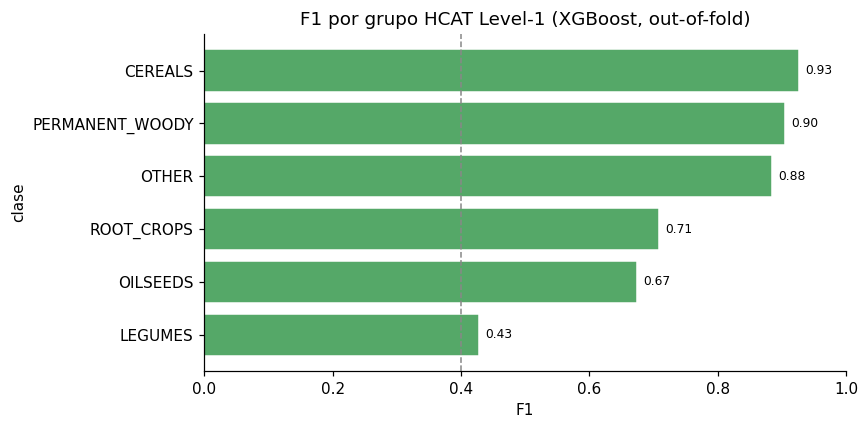

**F1 por grupo HCAT Level-1** (ordenado por id de grupo):

label_id,label_name,f1,support
i64,str,f64,i64
0,"""CEREALS""",0.9264,2738
1,"""LEGUMES""",0.4281,407
2,"""OILSEEDS""",0.6747,290
3,"""OTHER""",0.8843,3155
4,"""PERMANENT_WOODY""",0.9049,1269
5,"""ROOT_CROPS""",0.7089,132


**Las 6 clases planas más débiles** (confusión entre hermanas): su F1 cercano a cero es lo que el agrupamiento HCAT recupera.

label_id,label_name,f1,support
i64,str,f64,i64
9,"""Winter triticale""",0.0248,112
5,"""Spring barley""",0.0342,84
17,"""Sorghum""",0.1359,65
16,"""Mixed cereal""",0.1626,78
6,"""Sunflower""",0.3298,126
13,"""Leguminous fodder""",0.34,295


In [14]:
# grouped_label_names is already a dict {encoded_id: group_name}.
fig_hcat_f1 = plot_per_class_f1(
    hcat_result.grouped_y_true,
    hcat_result.grouped_y_pred,
    class_labels=sorted(hcat_result.grouped_label_names),
    class_names=hcat_result.grouped_label_names,
    weak_threshold=0.40,
    title='F1 por grupo HCAT Level-1 (XGBoost, out-of-fold)',
)
fig_hcat_f1.savefig(env.figures_dir / 'hcat_per_group_f1.png', bbox_inches='tight')
display(fig_hcat_f1)
plt.close(fig_hcat_f1)

display(Markdown('**F1 por grupo HCAT Level-1** (ordenado por id de grupo):'))
display(hcat_result.grouped_per_group)

weakest_flat = hcat_result.flat_per_class.sort('f1').head(6)
display(Markdown(
    '**Las 6 clases planas más débiles** (confusión entre hermanas): '
    'su F1 cercano a cero es lo que el agrupamiento HCAT recupera.'
))
display(weakest_flat)


### 8.5 Lectura del salto

El aumento del F1-macro al pasar de 18 clases a 6 grupos no es un truco para inflar la cifra: es la medida de **cuánto del error del esquema plano era confusión dentro de la misma familia agronómica**. Si el salto es grande, significa que el modelo ya distingue bien las familias (cereal vs leñoso vs oleaginosa) y que el residuo se concentra en separar cultivos que comparten firma. Ese diagnóstico orienta la fase siguiente: los modelos densos del Avance 4 tendrán que apoyarse en la **dinámica temporal intra-temporada** — no en una imagen-resumen anual — para empezar a separar los trigos entre sí.

## Conclusiones

**El patrón está validado.** Las tres familias de árboles (bagging, boosting clásico, boosting histogram-based) corren end-to-end sobre el subset en pocos minutos y los runs quedan registrados en MLflow. El mejor modelo del piloto (LightGBM, F1-macro `0.38` sobre 18 clases con las 185 features) queda muy cerca del valor histórico de XGBoost en el conjunto completo (`0.41`): el subset reduce ligeramente la cifra a igual modelo, como se espera, y eso confirma que la metodología es estable para arrancar la corrida completa de `04_baseline.ipynb`.

**El hallazgo del piloto (sección 8).** La métrica sube en dos etapas, por motivos distintos que conviene no mezclar. El mejor modelo del bloque anterior (LightGBM sobre las 185 features) da `0.38` de F1-macro en 18 clases. Al pasar al escenario ganador de la ablación — XGBoost sobre 313 features (las 185 más el embedding AlphaEarth de 2018 y 2019) — el F1-macro de 18 clases sube a `0.54`. Ese salto combina dos efectos: el cambio de modelo y, sobre todo, la señal extra del embedding anual que las estadísticas espectrales no capturan (la corrida completa de `04_baseline.ipynb` aísla el aporte de AlphaEarth a igualdad de modelo). Después, medir ese mismo modelo sobre los 6 grupos HCAT en lugar de las 18 clases planas lo lleva de `0.54` a `0.75` (delta `+0.21`): ese tramo es puro error de confusión entre cultivos hermanos (trigo-con-trigo, cereal-con-cereal), no falta de señal. Leído por familias agronómicas, el baseline ya supera con holgura el umbral de referencia de `0.60`.

**Sobre las preguntas oficiales**:

- **P1 (algoritmo baseline)**: los 3 modelos tabulares cumplen el rol de baseline en pocos minutos sobre subset. La elección final del ganador queda en `04_baseline.ipynb` sobre el dataset completo, y la decisión de promoción para ensembles queda en `Avance3.Equipo17.ipynb`.
- **P4 (métrica adecuada)**: el imbalance ratio del subset (`57x` entre la clase más y menos frecuente) evidencia por qué la accuracy es engañosa (predecir solo la clase mayoritaria daría una accuracy alta pero un F1-macro cercano a cero); por eso reportamos F1-macro como métrica principal y mostramos también el esquema agrupado para separar el error real del castigo por granularidad excesiva.

## Lo que sigue

- `04_baseline.ipynb` ejecuta los mismos 3 modelos sobre el conjunto completo + SHAP + learning curves + escenarios AlphaEarth vs S2 crudo.
- `04c_baseline.ipynb` mide qué bloques del fused aportan (ablación canónica).